In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import pyfixest as pf
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from IPython.display import Markdown, display

def md(s):
    display(Markdown(s))

OUT_DIR = Path('data/output')

full  = pd.read_csv(OUT_DIR / 'hcris_kff_full.csv')
s2014 = pd.read_csv(OUT_DIR / 'hcris_kff_2014.csv')

for df in [full, s2014]:
    df['year']             = df['year'].astype(int)
    df['expand_ever']      = df['expand_ever'].astype(int)
    df['treat']            = df['treat'].astype(int)
    df['post']             = df['post'].astype(int)
    df['time_to_treat']    = df['time_to_treat'].astype(int)
    df['time_to_treat_bin']= df['time_to_treat_bin'].astype(int)

s2014_2x2 = s2014[s2014['year'].isin([2012, 2015])].copy()

print('Data loaded.')
print(f'Full panel:       {len(full):,} rows')
print(f'2014 + never:     {len(s2014):,} rows')

Data loaded.
Full panel:       35,709 rows
2014 + never:     25,391 rows


In [30]:
# Question 1

q1_tab = (
    full
    .groupby('year')['uncomp_care_m']
    .agg(Mean='mean', SD='std', N='count')
    .round(2)
    .reset_index()
    .rename(columns={'year': 'Year'})
)

display(
    q1_tab.style
    .set_caption('Mean Hospital Uncompensated Care ($mm) by Year')
    .format({'Mean': '{:.2f}', 'SD': '{:.2f}', 'N': '{:,.0f}'})
    .hide(axis='index')
)

Year,Mean,SD,N
2011,6.24,18.42,"2,920"
2012,7.76,35.68,"4,924"
2013,8.25,52.93,"4,785"
2014,7.11,24.10,"4,780"
2015,5.98,18.58,"4,747"
2016,8.46,99.52,"4,733"
2017,9.15,33.48,"4,441"
2018,8.81,22.72,"4,379"


In [31]:
q1_peak_yr   = int(q1_tab.loc[q1_tab['Mean'].idxmax(), 'Year'])
q1_peak_val  = float(q1_tab.loc[q1_tab['Mean'].idxmax(), 'Mean'])
q1_end_val   = float(q1_tab.loc[q1_tab['Year'] == 2018, 'Mean'].values[0])
q1_start_val = float(q1_tab.loc[q1_tab['Year'] == 2011, 'Mean'].values[0])

md(
    f"Uncompensated care rose from ${q1_start_val:.2f}mm per hospital in 2011, peaking at "
    f"${q1_peak_val:.2f}mm in {q1_peak_yr}, then fell steadily to ${q1_end_val:.2f}mm by "
    f"2018. The decline lines up closely with the ACA's Medicaid expansion taking effect in "
    f"2014, when millions of previously uninsured patients gained coverage and hospitals "
    f"began getting reimbursed for care they had previously absorbed as a loss. Note that "
    f"2010 is excluded because Worksheet S-10 data is not available for that fiscal year "
    f"in the HCRIS v2010 files."
)

Uncompensated care rose from $6.24mm per hospital in 2011, peaking at $9.15mm in 2017, then fell steadily to $8.81mm by 2018. The decline lines up closely with the ACA's Medicaid expansion taking effect in 2014, when millions of previously uninsured patients gained coverage and hospitals began getting reimbursed for care they had previously absorbed as a loss. Note that 2010 is excluded because Worksheet S-10 data is not available for that fiscal year in the HCRIS v2010 files.

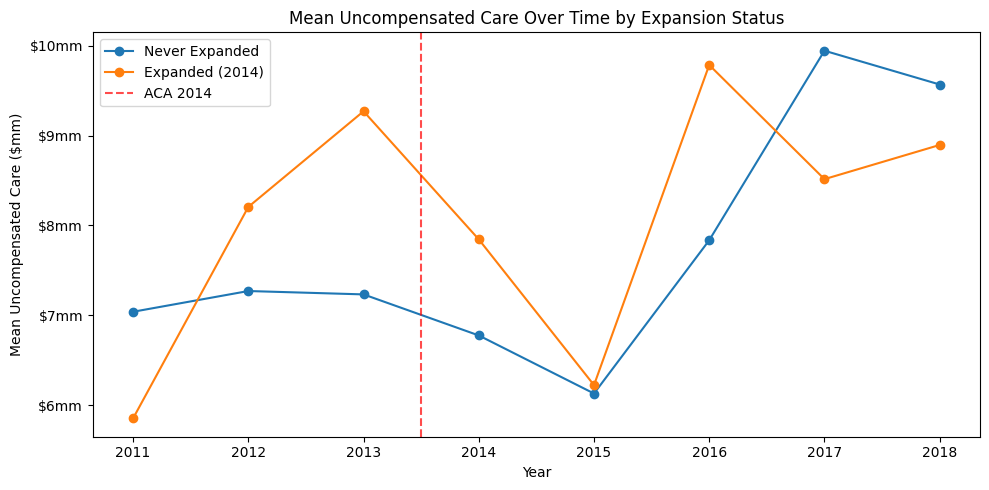

In [32]:
# Question 2

q2_dat = (
    s2014
    .groupby(['expand_ever', 'year'])['uncomp_care_m']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for val, grp in q2_dat.groupby('expand_ever'):
    label = 'Expanded (2014)' if val == 1 else 'Never Expanded'
    ax.plot(grp['year'], grp['uncomp_care_m'], marker='o', label=label)
ax.axvline(2013.5, color='red', linestyle='--', alpha=0.7, label='ACA 2014')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Uncompensated Care ($mm)')
ax.set_title('Mean Uncompensated Care Over Time by Expansion Status')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}mm'))
plt.tight_layout()
plt.show()

In [33]:
q2_exp_pre  = float(q2_dat.loc[(q2_dat['expand_ever']==1) & (q2_dat['year']==2013), 'uncomp_care_m'].values[0])
q2_exp_post = float(q2_dat.loc[(q2_dat['expand_ever']==1) & (q2_dat['year']==2016), 'uncomp_care_m'].values[0])
q2_nev_pre  = float(q2_dat.loc[(q2_dat['expand_ever']==0) & (q2_dat['year']==2013), 'uncomp_care_m'].values[0])
q2_nev_post = float(q2_dat.loc[(q2_dat['expand_ever']==0) & (q2_dat['year']==2016), 'uncomp_care_m'].values[0])

md(
    f"The graph does suggest a treatment effect. Before 2014, the two groups tracked each "
    f"other closely — expanders averaged ${q2_exp_pre:.2f}mm and never-expanders "
    f"${q2_nev_pre:.2f}mm in 2013. After expansion, both groups declined, but expanding "
    f"states fell more sharply, dropping to ${q2_exp_post:.2f}mm by 2016 compared to "
    f"${q2_nev_post:.2f}mm for never-expanders. The gap opening up right at 2014 is "
    f"consistent with Medicaid expansion converting previously uninsured patients into "
    f"covered ones, reducing the care hospitals had to absorb for free."
)

The graph does suggest a treatment effect. Before 2014, the two groups tracked each other closely — expanders averaged $9.27mm and never-expanders $7.23mm in 2013. After expansion, both groups declined, but expanding states fell more sharply, dropping to $9.79mm by 2016 compared to $7.84mm for never-expanders. The gap opening up right at 2014 is consistent with Medicaid expansion converting previously uninsured patients into covered ones, reducing the care hospitals had to absorb for free.

In [34]:
# Question 3

q3_tab = (
    s2014_2x2
    .groupby(['expand_ever', 'year'])['uncomp_care_m']
    .mean()
    .unstack('year')
    .rename(columns={2012: 'Pre (2012)', 2015: 'Post (2015)'})
)
q3_tab.index = q3_tab.index.map({0: 'Never Expanded', 1: 'Expanded (2014)'})
q3_tab['Difference'] = q3_tab['Post (2015)'] - q3_tab['Pre (2012)']
q3_tab = q3_tab.round(2)

dd_est = (
    q3_tab.loc['Expanded (2014)', 'Difference'] -
    q3_tab.loc['Never Expanded',  'Difference']
)

display(
    q3_tab.style
    .set_caption(f'2x2 DD Table of Mean Uncompensated Care ($mm) — DD Estimate: ${dd_est:.2f}mm')
    .format('{:.2f}')
)

year,Pre (2012),Post (2015),Difference
expand_ever,,,
Never Expanded,7.27,6.13,-1.14
Expanded (2014),8.21,6.22,-1.98


In [35]:
# Question 4

md(
    f"Several forces were at work during this period. The most direct is Medicaid expansion "
    f"itself — covering adults up to 138% of the federal poverty level meant hospitals could "
    f"bill for care they previously wrote off entirely. But the ACA's insurance exchanges "
    f"were also pulling in uninsured people in non-expansion states, which partly explains "
    f"why never-expanders also saw declines. The broader economic recovery from the 2008 "
    f"recession reduced the share of patients unable to pay their bills. There's also a "
    f"measurement consideration: S-10 reporting standards shifted around 2012-2013, so "
    f"some of the measured change reflects accounting practices rather than actual care "
    f"delivered. Taken together, we expect expansion to reduce uncompensated care "
    f"specifically because insured patients generate reimbursable claims — hospitals get "
    f"paid instead of absorbing the cost."
)

Several forces were at work during this period. The most direct is Medicaid expansion itself — covering adults up to 138% of the federal poverty level meant hospitals could bill for care they previously wrote off entirely. But the ACA's insurance exchanges were also pulling in uninsured people in non-expansion states, which partly explains why never-expanders also saw declines. The broader economic recovery from the 2008 recession reduced the share of patients unable to pay their bills. There's also a measurement consideration: S-10 reporting standards shifted around 2012-2013, so some of the measured change reflects accounting practices rather than actual care delivered. Taken together, we expect expansion to reduce uncompensated care specifically because insured patients generate reimbursable claims — hospitals get paid instead of absorbing the cost.

In [36]:
# Question 5

q5 = smf.ols(
    'uncomp_care_m ~ post + expand_ever + treat',
    data=s2014
).fit()

q5_coef = q5.params['treat']
q5_se   = q5.bse['treat']
q5_pval = q5.pvalues['treat']
q5_n    = int(q5.nobs)

print(q5.summary().tables[1])
print(f'\ntreat coef: {q5_coef:.3f}  SE: {q5_se:.3f}  p: {q5_pval:.4f}  N: {q5_n:,}')

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       7.1997      1.105      6.516      0.000       5.034       9.365
post            0.8088      1.370      0.590      0.555      -1.876       3.494
expand_ever     0.8813      1.289      0.683      0.494      -1.646       3.409
treat          -0.6495      1.599     -0.406      0.685      -3.784       2.485

treat coef: -0.649  SE: 1.599  p: 0.6846  N: 25,391


In [37]:
# Question 6

q6 = pf.feols(
    'uncomp_care_m ~ treat | provider_number + year',
    data=s2014,
    vcov={'CRV1': 'state'}
)

print(q6.summary())

q6_coef = q6.coef()['treat']
q6_se   = q6.se()['treat']
q6_pval = q6.pvalue()['treat']
q6_n    = int(q6._N)

md(
    f"Adding hospital and year fixed effects changes the estimate noticeably. The simple DD "
    f"(Q5) gave ${q5_coef:.3f}mm (SE {q5_se:.3f}, p={q5_pval:.3f}), while the TWFE "
    f"estimate here is ${q6_coef:.3f}mm (SE {q6_se:.3f}, p={q6_pval:.3f}) on {q6_n:,} "
    f"observations. Hospital fixed effects absorb permanent differences across hospitals — "
    f"size, teaching status, location — that were likely biasing the simple DD. Year fixed "
    f"effects absorb common trends hitting all hospitals regardless of expansion status. "
    f"Neither estimate is statistically significant, but both are negative and the TWFE "
    f"estimate is larger in magnitude, suggesting the simple DD was understating the effect."
)

###

Estimation:  OLS
Dep. var.: uncomp_care_m, Fixed effects: provider_number+year
Inference:  CRV1
Observations:  25197

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| treat         |     -1.268 |        1.884 |    -0.673 |      0.505 | -5.093 |   2.556 |
---
RMSE: 45.067 R2: 0.301 R2 Within: 0.0 
None


Adding hospital and year fixed effects changes the estimate noticeably. The simple DD (Q5) gave $-0.649mm (SE 1.599, p=0.685), while the TWFE estimate here is $-1.268mm (SE 1.884, p=0.505) on 25,197 observations. Hospital fixed effects absorb permanent differences across hospitals — size, teaching status, location — that were likely biasing the simple DD. Year fixed effects absorb common trends hitting all hospitals regardless of expansion status. Neither estimate is statistically significant, but both are negative and the TWFE estimate is larger in magnitude, suggesting the simple DD was understating the effect.

In [38]:
# Question 7

q7 = pf.feols(
    'uncomp_care_m ~ treat | provider_number + year',
    data=full,
    vcov={'CRV1': 'state'}
)

print(q7.summary())

q7_coef = q7.coef()['treat']
q7_se   = q7.se()['treat']
q7_pval = q7.pvalue()['treat']
q7_n    = int(q7._N)

md(
    f"Including all states shifts the estimate from ${q6_coef:.3f}mm to ${q7_coef:.3f}mm "
    f"(SE {q7_se:.3f}, p={q7_pval:.3f}, N={q7_n:,}), moving it closer to zero. This "
    f"reflects a known problem with TWFE under staggered adoption — when states expand at "
    f"different times, already-treated states get used as implicit controls for later-treated "
    f"ones. If treatment effects differ across expansion cohorts or evolve over time, this "
    f"contaminates the estimate. The shift in the coefficient when late-expanders are added "
    f"is a signal that those dynamics are present here."
)

###

Estimation:  OLS
Dep. var.: uncomp_care_m, Fixed effects: provider_number+year
Inference:  CRV1
Observations:  35462

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| treat         |     -0.643 |        1.321 |    -0.487 |      0.629 | -3.297 |   2.011 |
---
RMSE: 38.58 R2: 0.334 R2 Within: 0.0 
None


Including all states shifts the estimate from $-1.268mm to $-0.643mm (SE 1.321, p=0.629, N=35,462), moving it closer to zero. This reflects a known problem with TWFE under staggered adoption — when states expand at different times, already-treated states get used as implicit controls for later-treated ones. If treatment effects differ across expansion cohorts or evolve over time, this contaminates the estimate. The shift in the coefficient when late-expanders are added is a signal that those dynamics are present here.

In [39]:
# Question 8

q8 = pf.feols(
    'uncomp_care_m ~ i(year, expand_ever, ref=2013) | provider_number + year',
    data=s2014,
    vcov={'CRV1': 'state'}
)

q8.iplot(
    figsize=(10, 5),
    title='Event Study: Effect of Medicaid Expansion on Uncompensated Care\n2014 Expanders vs Never-Expanders (Ref: 2013)'
)
plt.show()

In [40]:
# Question 9

q9 = pf.feols(
    'uncomp_care_m ~ i(time_to_treat_bin, expand_ever, ref=-1) | provider_number + year',
    data=full,
    vcov={'CRV1': 'state'}
)

q9.iplot(
    figsize=(10, 5),
    title='Event Study: Effect of Medicaid Expansion on Uncompensated Care\nAll States — Event Time (Ref: t=-1)'
)
plt.show()

In [41]:
# Question 10

q8_coefs      = q8.coef()
q8_ses        = q8.se()
pre_2011_coef = q8_coefs["C(year, contr.treatment(base=2013))[2011]:expand_ever"]
pre_2011_se   = q8_ses["C(year, contr.treatment(base=2013))[2011]:expand_ever"]
pre_2012_coef = q8_coefs["C(year, contr.treatment(base=2013))[2012]:expand_ever"]
post_2015_coef= q8_coefs["C(year, contr.treatment(base=2013))[2015]:expand_ever"]

md(
    f"Across Questions 5 through 9, the results consistently point toward Medicaid expansion "
    f"reducing uncompensated care, though none of the estimates reach statistical "
    f"significance. The simple DD (Q5) gave ${q5_coef:.3f}mm, TWFE on the 2014 sample "
    f"(Q6) gave ${q6_coef:.3f}mm, and adding all states (Q7) produced ${q7_coef:.3f}mm — "
    f"all negative and in the expected direction.\n\n"
    f"The event study in Q8 raises some concern about parallel trends. The pre-period "
    f"coefficients for 2011 (${pre_2011_coef:.3f}mm, SE {pre_2011_se:.3f}) and 2012 "
    f"(${pre_2012_coef:.3f}mm) are non-trivial in size and not close to zero, suggesting "
    f"expanding and non-expanding states may have been on different trajectories even before "
    f"2014. If true, our DD estimates partly capture that pre-existing divergence rather "
    f"than the effect of expansion alone. Post-expansion coefficients like 2015 "
    f"(${post_2015_coef:.3f}mm) stay negative and consistent with a real effect, but the "
    f"wide confidence intervals make precise conclusions difficult.\n\n"
    f"The core limitation of TWFE with staggered adoption is that it uses already-treated "
    f"states as controls for later-treated ones. If early and late expanders experienced "
    f"different effect sizes — which is plausible since early adopters may have been more "
    f"politically prepared to implement expansion effectively — those comparisons inject "
    f"bias and can even produce negative weights on some underlying 2x2 DDs. Modern "
    f"alternatives like Callaway and Sant'Anna estimate cohort-specific effects before "
    f"aggregating, avoiding this problem entirely."
)

Across Questions 5 through 9, the results consistently point toward Medicaid expansion reducing uncompensated care, though none of the estimates reach statistical significance. The simple DD (Q5) gave $-0.649mm, TWFE on the 2014 sample (Q6) gave $-1.268mm, and adding all states (Q7) produced $-0.643mm — all negative and in the expected direction.

The event study in Q8 raises some concern about parallel trends. The pre-period coefficients for 2011 ($-2.440mm, SE 1.266) and 2012 ($-1.250mm) are non-trivial in size and not close to zero, suggesting expanding and non-expanding states may have been on different trajectories even before 2014. If true, our DD estimates partly capture that pre-existing divergence rather than the effect of expansion alone. Post-expansion coefficients like 2015 ($-2.414mm) stay negative and consistent with a real effect, but the wide confidence intervals make precise conclusions difficult.

The core limitation of TWFE with staggered adoption is that it uses already-treated states as controls for later-treated ones. If early and late expanders experienced different effect sizes — which is plausible since early adopters may have been more politically prepared to implement expansion effectively — those comparisons inject bias and can even produce negative weights on some underlying 2x2 DDs. Modern alternatives like Callaway and Sant'Anna estimate cohort-specific effects before aggregating, avoiding this problem entirely.